In [1]:
import torch
from torch import nn
from torch.nn import functional as F

In [2]:
class Residual(nn.Module):
    def __init__(self, num_channels, use_1x1_conv=False, strides=1):
        super().__init__()
        self.conv1 = nn.LazyConv2d(num_channels, kernel_size=3, padding=1, stride=strides)
        self.conv2 = nn.LazyConv2d(num_channels, kernel_size=3, padding=1)

        if use_1x1_conv:
            self.conv3 = nn.LazyConv2d(num_channels, kernel_size=1, stride=strides)
        else:
            self.conv3 = None
        
        self.bn1 = nn.LazyBatchNorm2d()
        self.bn2 = nn.LazyBatchNorm2d()

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)
        Y += X
        return F.relu(Y)

In [3]:
X = torch.randn(4, 3, 6, 6) # batch = 4, channel = 3, ảnh 6x6
blk = Residual(3) # giữ nguyên channel = 3
blk.forward(X).shape

torch.Size([4, 3, 6, 6])

In [4]:
blk2 = Residual(6, use_1x1_conv=True, strides=2) # tăng lên 6 channel, giảm kích thước ảnh về 3 X 3 bằng stride = 2
blk2.forward(X).shape

torch.Size([4, 6, 3, 3])

In [6]:
class ResNet(nn.Module): #resnet-18
    def b1(self):
        return nn.Sequential(
            nn.LazyConv2d(out_channels=64, kernel_size=7, stride=2, padding=3),
            nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
    
    def block(self, num_residuals, num_channels, first_block=False):
        block = []
        for i in range(num_residuals):
            if i == 0 and not first_block:
                block.append(Residual(num_channels=num_channels, use_1x1_conv=True, strides=2))
            else:
                block.append(Residual(num_channels=num_channels))
        return nn.Sequential(*block)
    
    def last(self, num_class):
        return nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.LazyLinear(out_features=num_class)
        )
    
    def __init__(self, blocks_info, num_class=10):
        super().__init__()
        blocks = []
        blocks.append(self.b1())

        for i, block_info in enumerate(blocks_info):
            blocks.append(self.block(*block_info, first_block=(i==0)))
        
        blocks.append(self.last(num_class=num_class))

        self.net = nn.Sequential(*blocks)

    def layer_summary(self, X_shape):
        X = torch.randn(X_shape)
        for layer in self.net:
            X = layer(X)
            print(layer.__class__.__name__, 'output shape:\t', X.shape)
    
    def forward(self, X):
        return self.net(X)

In [7]:
model = ResNet(((2, 64), (2, 128), (2, 256), (2, 512)), num_class=10)

model.layer_summary((1, 3, 96, 96))

Sequential output shape:	 torch.Size([1, 64, 24, 24])
Sequential output shape:	 torch.Size([1, 64, 24, 24])
Sequential output shape:	 torch.Size([1, 128, 12, 12])
Sequential output shape:	 torch.Size([1, 256, 6, 6])
Sequential output shape:	 torch.Size([1, 512, 3, 3])
Sequential output shape:	 torch.Size([1, 10])


In [8]:
class ResNet18(ResNet):
    def __init__(self, num_classes=10):
        super().__init__(((2, 64), (2, 128), (2, 256), (2, 512)), num_classes)

ResNet18().layer_summary((1, 1, 96, 96))

Sequential output shape:	 torch.Size([1, 64, 24, 24])
Sequential output shape:	 torch.Size([1, 64, 24, 24])
Sequential output shape:	 torch.Size([1, 128, 12, 12])
Sequential output shape:	 torch.Size([1, 256, 6, 6])
Sequential output shape:	 torch.Size([1, 512, 3, 3])
Sequential output shape:	 torch.Size([1, 10])


In [9]:
import torchvision
from torchvision import transforms

trans = torchvision.transforms.Compose([transforms.Resize((96, 96)), transforms.ToTensor()])

data_train = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    transform=trans,
    download=True)
data_val = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    transform=trans,
    download=True
)

len(data_train), len(data_val)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 169kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.20MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 27.1MB/s]


(60000, 10000)

In [10]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    data_train,
    batch_size=128,
    shuffle=True
)

val_loader = DataLoader(
    data_val,
    batch_size=128,
    shuffle=False
)

In [ ]:
from torch import optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = ResNet18(10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(params=model.parameters(), lr=0.01)

epochs = 30

loss_histoty = {"train": [], "val": []}

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_hat = model(X_batch)

        loss = criterion(y_hat, y_batch)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_loss += loss.item()
    train_loss_avg = train_loss / len(train_loader)
    loss_histoty["train"].append(train_loss_avg)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_hat = model(X_batch)
            loss = criterion(y_hat, y_batch)
            val_loss += loss.item()
        
        val_loss_avg = val_loss / len(val_loader)
        loss_histoty["val"].append(val_loss_avg)
    print(f"Epoch {epoch+1}/{epochs}: Train Loss: {train_loss_avg}, Val Loss: {val_loss_avg}")

Using device: cuda
Epoch 1/30: Train Loss: 0.43760627864012075, Val Loss: 0.42725484205197684
Epoch 2/30: Train Loss: 0.24575383003268922, Val Loss: 0.35960215858266326
Epoch 3/30: Train Loss: 0.19173128794886665, Val Loss: 0.2841770695168761
Epoch 4/30: Train Loss: 0.15114976153540205, Val Loss: 0.24547112256854395
Epoch 5/30: Train Loss: 0.12004928178052658, Val Loss: 0.24332214005385774
Epoch 6/30: Train Loss: 0.09503489885248863, Val Loss: 0.28521256328006334
Epoch 7/30: Train Loss: 0.06756032337901244, Val Loss: 0.346711227222334
Epoch 8/30: Train Loss: 0.052045812883944526, Val Loss: 0.2924253681226622
Epoch 9/30: Train Loss: 0.043533843750360485, Val Loss: 0.27385822287465955
Epoch 10/30: Train Loss: 0.03326158790882907, Val Loss: 0.28530924757824666
Epoch 11/30: Train Loss: 0.023553771864392482, Val Loss: 0.3222877718036688
Epoch 12/30: Train Loss: 0.015261168661179826, Val Loss: 0.3391801912950564
Epoch 13/30: Train Loss: 0.007365863159872782, Val Loss: 0.3287039933891236
Epoc

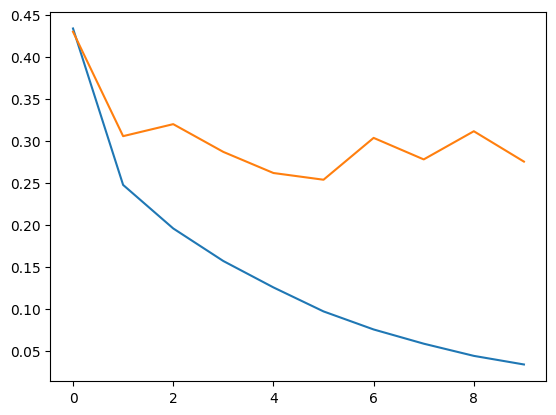

In [13]:
from matplotlib import pyplot as plt

plt.plot(loss_histoty["train"], label="train_loss")
plt.plot(loss_histoty["val"], label = "val_loss")

plt.show()

In [ ]:
class ResNeXtBlock(nn.Module):
    """The ResNeXt block."""
    def __init__(self, num_channels, groups, bot_mul, use_1x1conv=False, # bot_mul < 1 giảm số kệnh trước khi chia thành g nhóm
                 strides=1):
        super().__init__()
        bot_channels = int(round(num_channels * bot_mul)) # tổng số channel sau khi giảm số lượng
        self.conv1 = nn.LazyConv2d(bot_channels, kernel_size=1, stride=1)
        self.conv2 = nn.LazyConv2d(bot_channels, kernel_size=3,
                                   stride=strides, padding=1,
                                   groups=bot_channels//groups) # groups parameter ở đây là số lượng channel của 1 group (in_channel) ko phải số lượng group
        self.conv3 = nn.LazyConv2d(num_channels, kernel_size=1, stride=1)
        self.bn1 = nn.LazyBatchNorm2d()
        self.bn2 = nn.LazyBatchNorm2d()
        self.bn3 = nn.LazyBatchNorm2d()
        if use_1x1conv:
            self.conv4 = nn.LazyConv2d(num_channels, kernel_size=1,
                                       stride=strides)
            self.bn4 = nn.LazyBatchNorm2d()
        else:
            self.conv4 = None

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = F.relu(self.bn2(self.conv2(Y)))
        Y = self.bn3(self.conv3(Y))
        if self.conv4:
            X = self.bn4(self.conv4(X))
        return F.relu(Y + X)

In [3]:
blk = ResNeXtBlock(32, 16, 1)
X = torch.randn(4, 32, 96, 96)
blk(X).shape

torch.Size([4, 32, 96, 96])